#  1 Loading Accident Data

In [69]:
import numpy as np
data = np.loadtxt("coal_mining_accident_data.dat", delimiter=None)  
data =  data.flatten(order="F") # Now all data is in a single array 190 delimiters for 191 incidents
print(data.shape)
print(data)

(190,)
[1.570e+02 1.230e+02 2.000e+00 1.240e+02 1.200e+01 4.000e+00 1.000e+01
 2.160e+02 8.000e+01 1.200e+01 3.300e+01 6.600e+01 2.320e+02 8.260e+02
 4.000e+01 1.200e+01 2.900e+01 1.900e+02 9.700e+01 6.500e+01 1.860e+02
 2.300e+01 9.200e+01 1.970e+02 4.310e+02 1.600e+01 1.540e+02 9.500e+01
 2.500e+01 1.900e+01 7.800e+01 2.020e+02 3.600e+01 1.100e+02 2.760e+02
 1.600e+01 8.800e+01 2.250e+02 5.300e+01 1.700e+01 5.380e+02 1.870e+02
 3.400e+01 1.010e+02 4.100e+01 1.390e+02 4.200e+01 1.000e+00 2.500e+02
 8.000e+01 3.000e+00 3.240e+02 5.600e+01 3.100e+01 9.600e+01 7.000e+01
 4.100e+01 9.300e+01 2.400e+01 9.100e+01 1.430e+02 1.600e+01 2.700e+01
 1.440e+02 4.500e+01 6.000e+00 2.080e+02 2.900e+01 1.120e+02 4.300e+01
 1.930e+02 1.340e+02 4.200e+02 9.500e+01 1.250e+02 3.400e+01 1.270e+02
 2.180e+02 2.000e+00 0.000e+00 3.780e+02 3.600e+01 1.500e+01 3.100e+01
 2.150e+02 1.100e+01 1.370e+02 4.000e+00 1.500e+01 7.200e+01 9.600e+01
 1.240e+02 5.000e+01 1.200e+02 2.030e+02 1.760e+02 5.500e+01 9.300e+01

[  1.   1.   1. ... 190. 190. 191.]


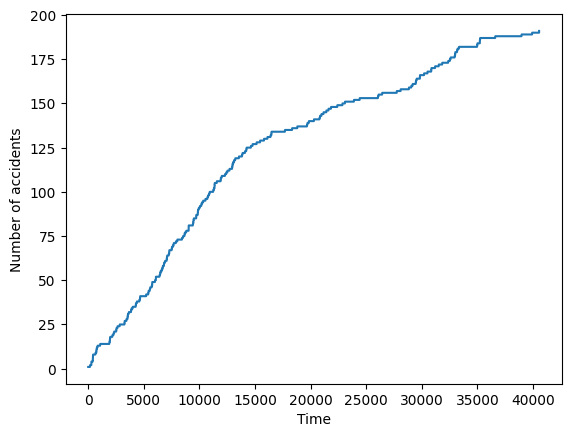

In [70]:
# Plot cumulative sum of accidents over time
import matplotlib.pyplot as plt
cumulative_accidents = np.zeros(40550) # Start with the first accident
cumulative_accidents[0] = 1
i = 0 
j = 0 # next
for interval in data:
    start = cumulative_accidents[i]
    j += int(interval)
    while i < j:
        cumulative_accidents[i] = start
        i += 1 # This ends when i == j
    cumulative_accidents[j] = start + 1

print(cumulative_accidents)
plt.plot(range(40550), cumulative_accidents)
plt.xlabel("Time")
plt.ylabel("Number of accidents")
plt.show()


# 2a Plain vs Even order stats

The plain-order-statistics draws k points and sorts them. This allows the adjacent points to be very close together. By drawing more points than required and then taking alterating points from a sorted array of them, this forces a degree of seapration between the change points we are using as a prior. This reduces the probability of very small gaps between neighbours, favouring more separated change points.

This can improve performance because it encourages the model to use all of the change points: if two change points are too close together in the prior, the model might fit them as one.

In [71]:
np.random.seed(1701)

def find_gaps(samples, L=40550):
    left = [0]
    right = [L]
    full = np.concatenate([left, samples, right])
    gaps = [(full[i] - full[i-1]) for i in range(1, len(full))]
    return gaps

def even_stats(k=4, L=40550):
    even_rand = [np.random.uniform() for i in range((2*k+1))]
    even_sorted = np.sort(even_rand)
    even_unscaled = even_sorted[1::2]    
    even = even_unscaled * L
    return even

def plain_stats(k=4, L=40550):
    plain_rand = [np.random.uniform() for i in range(k)]
    plain_unscaled = np.sort(plain_rand) 
    plain = plain_unscaled * L
    return plain


[ 3626.51765186  8630.75052304 21035.06661331 35683.30688448]
[ 6913.10752386 13351.78739706 13357.34922427 27637.26818534]


C:\Users\Joey\AppData\Local\Temp\ipykernel_28836\2135258418.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


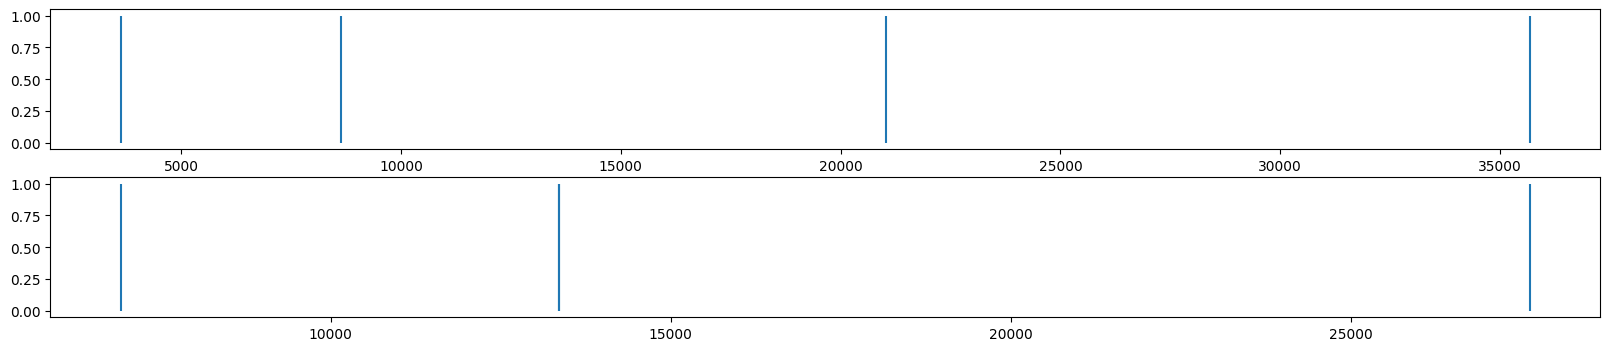

In [72]:
# Plot single example
np.random.seed(1701)
k = 4

# Even order stats
# even_rand = [np.random.uniform() for i in range((2*k+1))]
# even_sorted = np.sort(even_rand)
# even = even_sorted[1::2]
even = even_stats()

# Plain stats
# plain_rand = [np.random.uniform() for i in range(k)]
# plain = np.sort(plain_rand)
plain = plain_stats()

print(even)
print(plain)

fig, ax = plt.subplots(2, figsize=(20, 4))

ax[0].vlines(even, 0, 1)
ax[1].vlines(plain,0, 1)
fig.show()




The middle line on the plain-statistics draw (the bottom subplot) shows is actually two draws that are very close to one another. We can try to look at this for a larger number of draws by plotting the distribution of the size of gaps between the generated change points.

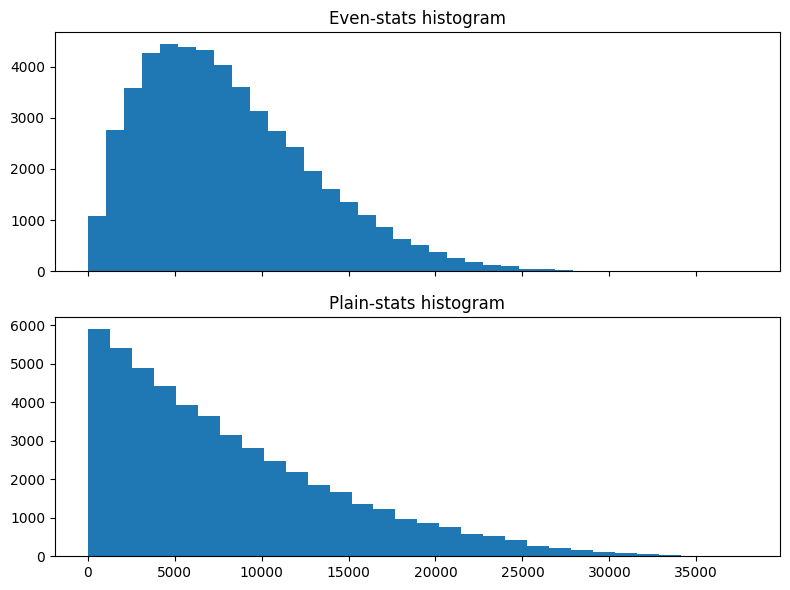

In [73]:
even_gaps = []
plain_gaps =[]
for i in range(0,10000):
    even_gaps.append(find_gaps(even_stats(k=4)))
    plain_gaps.append(find_gaps(plain_stats(k=4)))

even_gaps = np.array(even_gaps).flatten()
plain_gaps = np.array(plain_gaps).flatten()

# Plot them in two subplot histograms

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axs[0].hist(even_gaps, bins=30)
axs[0].set_title("Even-stats histogram")

axs[1].hist(plain_gaps, bins=30)
axs[1].set_title("Plain-stats histogram")

plt.tight_layout()
plt.show()

This shows that our even-stats regime reduces the probability of very close together initial change-points. To have very high separations, the points have to be clumped at the ends so the reduction in clumping behaviour will also have the side effect of reducing very separated points too. This creates a consistent separation between change points.

# 2b Even-order statistics prior analysis

COME BACK TO THIS HOPO HOPO


# 3 Constant Rate Model
Model $M_0$ has constant rate $h_0$.
- k = 0 means no change points
- The heights are iid from $\Gamma(\alpha,\beta)$
- $\alpha = 1$, $\beta = 200$
- $P(h)=\frac{\beta^\alpha}{\Gamma(\alpha)} e^{-\beta h}, \qquad h>0$ is then the prior over $h_0$ in model $M_0$: $\pi(h_0|M_0)$
- The posterior $P(h_0|\{I_i\},M_0) = \frac{}{}$


-1217.0924811139914
-1210.022781756996
0.0


C:\Users\Joey\AppData\Local\Temp\ipykernel_28836\1808235911.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


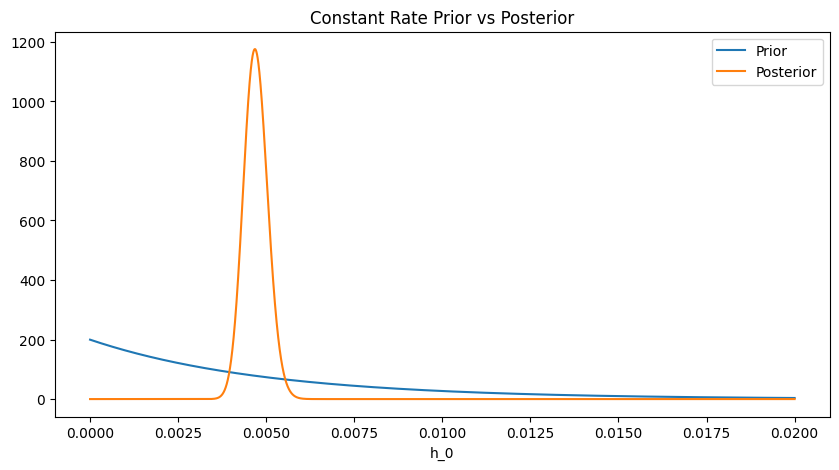

In [74]:
# Prior
def cr_prior(h_0):
    return 200 * np.exp(-200 * h_0)

# Integrand
def cr_LnPiL(h_0):
    return np.log(200) + 191 * np.log(h_0) + -40750 * h_0

# Calculate Z
h_0_vals = np.linspace(1e-5, 0.02, 20000, dtype=np.longdouble)
cr_prior_vals = cr_prior(h_0_vals)
cr_LnPiL_vals = cr_LnPiL(h_0_vals)
m = max(cr_LnPiL_vals)
cr_LnPiL_vals_shift = cr_LnPiL_vals - m
unscaled_z = np.trapezoid(np.exp(cr_LnPiL_vals_shift), h_0_vals)
log_z = m + np.log(unscaled_z)
print(log_z)

z = np.exp(m) * unscaled_z

print(m)
print(z)

log_post = cr_LnPiL(h_0_vals) - log_z
cr_post = np.exp(log_post)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(h_0_vals, cr_prior_vals, label="Prior")
ax.plot(h_0_vals, cr_post, label="Posterior")
ax.set_xlabel("h_0")
ax.set_title("Constant Rate Prior vs Posterior")
ax.legend()
fig.show()

# fig, ax = plt.subplots(1,2, figsize=(10, 5))
# ax[0].plot(h_0_vals, cr_prior_vals, label="Prior")
# ax[1].plot(h_0_vals, cr_post, label="Posterior")
# ax[0].set_xlabel("h_0")
# ax[1].set_xlabel("h_0")
# ax[0].set_title("Constant Rate Prior")
# ax[1].set_title("Posterior")
# fig.show()



# 4a

In [75]:
# For the log likelihoods it will be useful to have an array that has the cumulative days since 0 for each of the 191 accidents
cumulative_days = np.concatenate([[0], np.cumsum(data)]) #The array indices of the days on which accidents occurred (days-1)
len(data)
print(cumulative_days) #If we start at day 0 the final day will be numbered 549

[    0.   157.   280.   282.   406.   418.   422.   432.   648.   728.
   740.   773.   839.  1071.  1897.  1937.  1949.  1978.  2168.  2265.
  2330.  2516.  2539.  2631.  2828.  3259.  3275.  3429.  3524.  3549.
  3568.  3646.  3848.  3884.  3994.  4270.  4286.  4374.  4599.  4652.
  4669.  5207.  5394.  5428.  5529.  5570.  5709.  5751.  5752.  6002.
  6082.  6085.  6409.  6465.  6496.  6592.  6662.  6703.  6796.  6820.
  6911.  7054.  7070.  7097.  7241.  7286.  7292.  7500.  7529.  7641.
  7684.  7877.  8011.  8431.  8526.  8651.  8685.  8812.  9030.  9032.
  9032.  9410.  9446.  9461.  9492.  9707.  9718.  9855.  9859.  9874.
  9946. 10042. 10166. 10216. 10336. 10539. 10715. 10770. 10863. 10922.
 11237. 11296. 11357. 11358. 11371. 11560. 11905. 11925. 12006. 12292.
 12406. 12514. 12702. 12935. 12963. 12985. 13046. 13124. 13223. 13549.
 13824. 13878. 14095. 14208. 14240. 14628. 14779. 15140. 15452. 15806.
 16113. 16388. 16466. 16483. 17688. 18332. 18799. 19670. 19718. 19841.
 20297

- For emcee we need to define a good log probability to sample
- The requirements that the change points have to be sorted and that the heights have to be positive complicates matters somewhat.
- To force ordering, we can sample gaps between change points to allow us to order the change points afterwards.
- To force positivity of heights we can sample from some latent distribution z and take the transform $h_j = e^{z_j}$

In [90]:
from scipy.special import gammaln

def LnPost(theta, data=cumulative_days):
    """
    Returns the log posterior for the change points and heights given the data in cumulative_days

    Inputs:
        - theta: an array first of k gaps (calc k+1 from L) between change points and then of k+1 heights, so the length of theta is 2k+1 (model params)
        - data: an array of cumulative days on which accidents occurred (data)

    Outputs:
        - log posterior value for the given theta and data
    """
    k = int((len(theta) - 1) / 2)
    gaps = theta[0:k]
    heights = theta[k:]

    # final gap 
    final_gap = 40550 - np.sum(gaps)
    gaps = np.append(gaps, final_gap)

    # safety
    if np.any(gaps <= 0):
        return -np.inf
    if np.any(heights <= 0):
        return -np.inf

    # log prior calculation: chance points prior
    alpha = np.ones(k+1) * 2

    ln_gaps = np.log(gaps)
    sum_ln_gaps = np.sum(ln_gaps)

    lnB = np.sum(gammaln(alpha)) - gammaln(np.sum(alpha))

    change_portion = (-1 * (2*k + 1)*np.log(40550)) - lnB + sum_ln_gaps  # the contribution of the change points to the prior

    # log prior calculation: heights prior
    height_portion = ((k+1) * np.log(200)) - (200 * np.sum(heights))

    # LnPrior
    LnPi = height_portion + change_portion

    # # log likelihood calculation
    # change_points = np.cumsum(gaps[:-1]) # the last gap is the gap between the last change point and L, we don't need it to reconstruct the change points
    # modified_change_points= np.concatenate([[0], change_points, [40550]])
    # log_term = 0
    # i = 0 # index for cumulative days
    # j = 0 # change points index
    # while j <= k: # there are k change points
    #     if i < len(data) and data[i] > modified_change_points[j]  and data[i] < modified_change_points[j+1]:
    #         log_term += np.log(heights[j])
    #         i += 1
    #     else:
    #         j += 1
    
    # segment_lengths = np.diff(modified_change_points)
    # integral_term = np.sum(heights * segment_lengths)
    # LnL = log_term - integral_term

    # reconstruct change points
    change_points = np.cumsum(gaps[:-1])
    edges = np.concatenate([[0], change_points, [40550]])
    seg_lengths = np.diff(edges)

    # count data in each segment
    counts = np.zeros(k + 1, dtype=int)
    for j in range(k + 1):
        left = edges[j]
        right = edges[j + 1]
        counts[j] = np.sum((data > left) & (data < right))

    LnL = np.sum(counts * np.log(heights) - heights * seg_lengths)

   

    # log posterior
    LnPost = LnPi + LnL
    return LnPost









In [92]:
# Now sample from this 
import emcee
import numpy as np

rng = np.random.default_rng(1701)


k = 1 # rn treat 1 change point, so we have 2 segments and 2 heights
ndim = 2*k + 1 # k gaps (plus 1 implied) and k+1 heights
nwalkers = 100

# Initial positions for all walkers: shape (nwalkers, ndim)
initial_positions = np.ones((nwalkers, ndim)) # shape (nwalkers, ndim)
for w in range(nwalkers):
    # k positive gaps summing to L
    gaps = rng.dirichlet(np.ones(k+1) * 2.0) * 40550
    gaps = gaps[:-1] # drop the final gap since it's implied by the others

    # k+1 positive heights from the prior
    heights = rng.exponential(scale=1/200, size=k+1)

    initial_positions[w] = np.concatenate([gaps, heights])

# move = emcee.moves.GaussianMove(cov=np.diag([1000]*k + [0.01]*(k+1))) # tune the proposal covariance for better acceptance
sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    LnPost,
    args=[cumulative_days],
)

sampler.run_mcmc(initial_positions, 10000, progress=True)


100%|██████████| 10000/10000 [01:15<00:00, 131.85it/s]


State([[1.33831328e+04 8.71708331e-03 2.70085986e-03]
 [1.43563487e+04 7.36495253e-03 2.53307230e-03]
 [1.42891670e+04 7.44158971e-03 2.19777124e-03]
 [1.46237335e+04 7.74962859e-03 2.62383914e-03]
 [1.25257681e+04 8.58389986e-03 2.52074211e-03]
 [1.32378968e+04 8.23431196e-03 2.72564265e-03]
 [1.52317778e+04 9.37165557e-03 1.95768180e-03]
 [1.32661163e+04 1.08029344e-02 2.99842007e-03]
 [1.48029289e+04 7.37222638e-03 2.59751303e-03]
 [1.45678825e+04 9.75422996e-03 2.79321750e-03]
 [1.65250149e+04 7.22034698e-03 2.81706844e-03]
 [1.35934427e+04 7.84360178e-03 2.60376306e-03]
 [1.44325406e+04 7.78814687e-03 2.47864533e-03]
 [1.42589253e+04 7.74163295e-03 2.56097018e-03]
 [1.54274723e+04 8.38860039e-03 2.54781102e-03]
 [1.42906785e+04 7.52902256e-03 2.86399309e-03]
 [1.42861825e+04 7.60186249e-03 2.28018190e-03]
 [1.48412021e+04 7.95292180e-03 2.14239300e-03]
 [1.45327657e+04 7.87558555e-03 1.97033414e-03]
 [1.42565691e+04 8.60511284e-03 1.90952678e-03]
 [1.55227087e+04 8.00572913e-03 2.

There are 1 change points


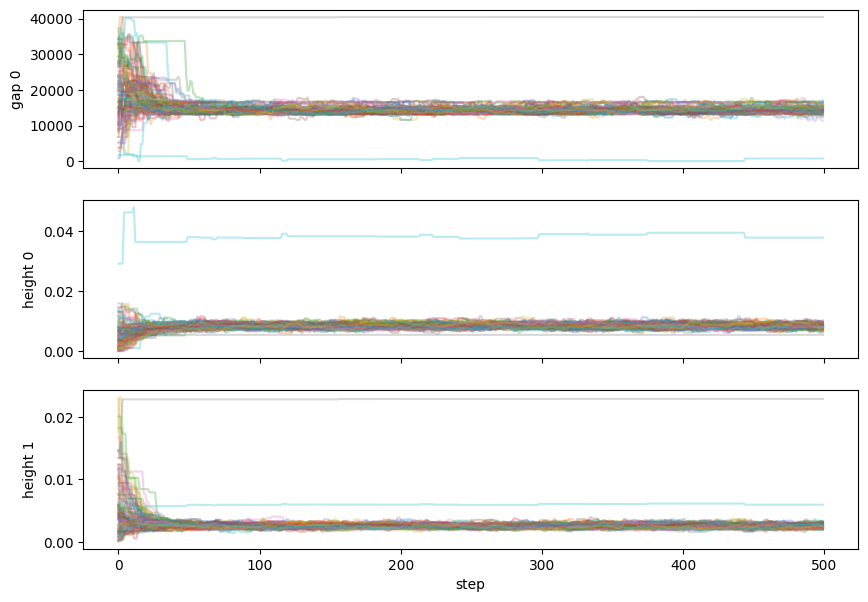

In [104]:
print(f"There are {k} change points")

fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()

labels = [f"gap {i}" for i in range(k)] + [f"height {j}" for j in range(k+1)]

for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:500,  :, i], alpha=0.3)
    ax.set_ylabel(labels[i])

axes[-1].set_xlabel("step")
plt.show()

- This looks pretty good. Most of the walked converge to the same area. 
- The change points are stored as gaps for calculations but because there is only one change point in this model, the location of the change point is the end of this gap 0 value.
- The change point value is quite reasonable as it is around the point in the above model where the rate drops noticeably.
- Out of these 100 walked, only 2 were outliers. These appear to be cases where the change points are at the extreme ends of the time series, implying that the model has reduced itself to a constant-rate model.
- This should not be a problem due to how rare it is.
- Manual observations indicate a burn-in period that ends before 100 steps so we can set that as a safe boundary to discard.
- We can also use the 10 * autocorrelation time benchmark to thin the samples.

In [ ]:
mean_frac =sampler.acceptance_fraction.mean()

taus = sampler.get_autocorr_time() # for thinning
mean_tau = np.mean(taus)
tau = int(max(taus)) # use the maximum autocorrelation time across all parameters for thinning

print(f"Mean acceptance fraction: {mean_frac:.3f}")
print(f"Mean autocorrelation time: {mean_tau:.2f} steps")

samples = sampler.get_chain(discard=100, thin=10*tau, flat=True) # shape (nwalkers * nsteps/thin, ndim) # review discard by plotting

Mean acceptance fraction: 0.506
Mean autocorrelation time: 48.64 steps


In [ ]:
# Produce the corner plot
import corner

In [82]:
# This is  for plotting the corner plots